In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import json
entropy_values = json.load(open("entropy.json", "r"))


In [2]:
# 2. DataFrame and metrics
df = pd.DataFrame({
    'Step': range(len(entropy_values)), 
    'Entropy': entropy_values
})

window_size = max(2, len(entropy_values) // 10) # Adjust window size as needed
df['Moving_Average'] = df['Entropy'].rolling(window=window_size).mean()
df['Rolling_Std'] = df['Entropy'].rolling(window=window_size).std()

# Set global plotting style
sns.set_theme(style="whitegrid")

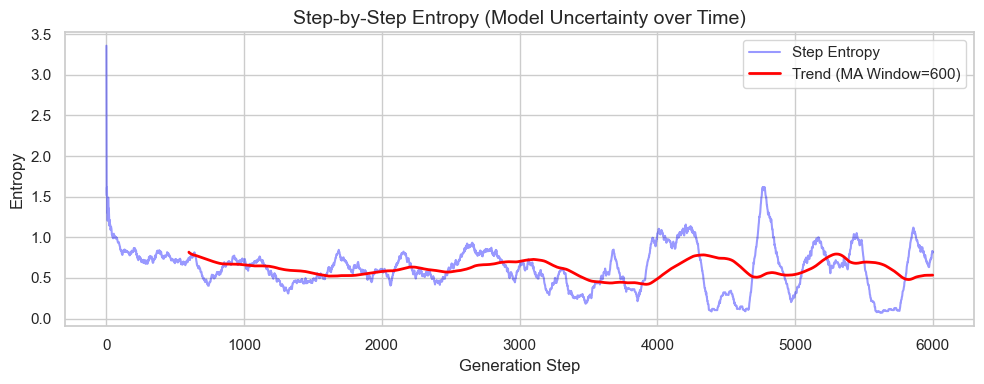

In [3]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Step', y='Entropy', alpha=0.4, label='Step Entropy', color='blue')
sns.lineplot(data=df, x='Step', y='Moving_Average', label=f'Trend (MA Window={window_size})', color='red', linewidth=2)
plt.title('Step-by-Step Entropy (Model Uncertainty over Time)', fontsize=14)
plt.ylabel('Entropy')
plt.xlabel('Generation Step')
plt.legend()
plt.tight_layout()
plt.show()

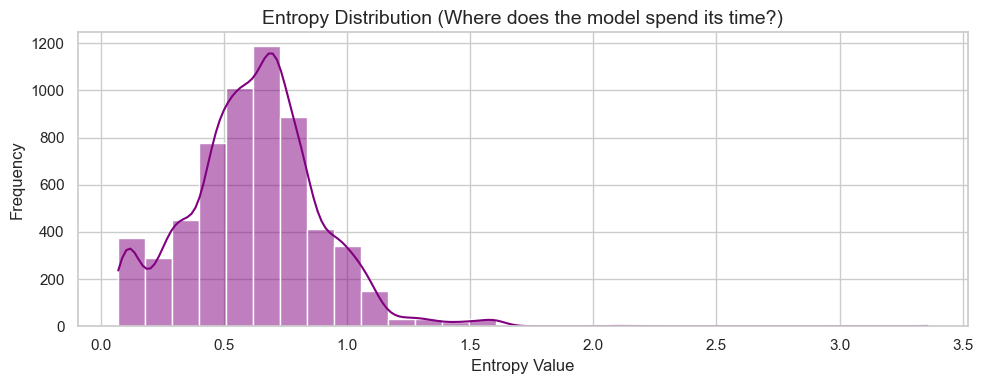

In [4]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Entropy', kde=True, bins=30, color='purple')
plt.title('Entropy Distribution (Where does the model spend its time?)', fontsize=14)
plt.xlabel('Entropy Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [5]:
np.max(entropy_values), np.min(entropy_values), np.mean(entropy_values), np.median(entropy_values), np.std(entropy_values)

(np.float64(3.3578853607177734),
 np.float64(0.07057355991564691),
 np.float64(0.6226013490494923),
 np.float64(0.6295140598256694),
 np.float64(0.26481167596649197))

In [6]:
len(entropy_values), len(df), window_size

(6000, 6000, 600)

In [7]:
# df = pd.DataFrame(entropy_values, columns=['Entropy'])

In [8]:
df[df['Entropy'] < 0.01]

,Step,Entropy,Moving_Average,Rolling_Std


In [9]:
low = df[df['Entropy'] < 0.01]

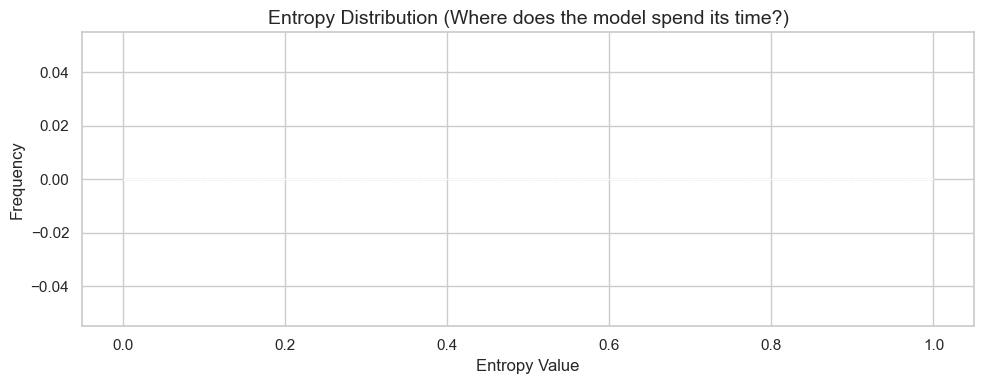

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(data=low, x='Entropy', kde=True, bins=30, color='purple')
plt.title('Entropy Distribution (Where does the model spend its time?)', fontsize=14)
plt.xlabel('Entropy Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

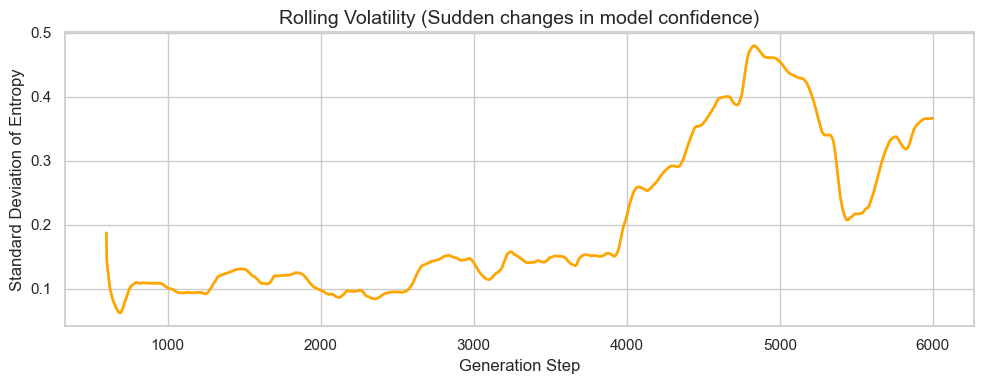

In [11]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Step', y='Rolling_Std', color='orange', linewidth=2)
plt.title('Rolling Volatility (Sudden changes in model confidence)', fontsize=14)
plt.ylabel('Standard Deviation of Entropy')
plt.xlabel('Generation Step')
plt.tight_layout()
plt.show()

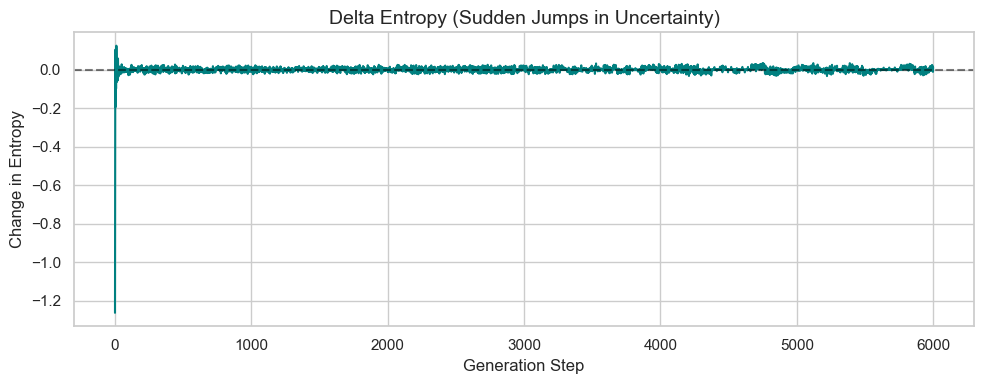

In [12]:
# Calculate the step-to-step difference
df['Delta_Entropy'] = df['Entropy'].diff()

plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Step', y='Delta_Entropy', color='teal')
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Zero baseline
plt.title('Delta Entropy (Sudden Jumps in Uncertainty)', fontsize=14)
plt.ylabel('Change in Entropy')
plt.xlabel('Generation Step')
plt.tight_layout()
plt.show()

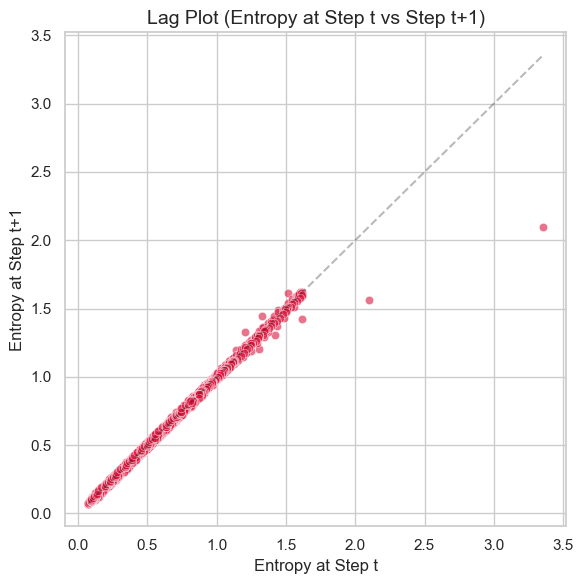

In [13]:
plt.figure(figsize=(6, 6))

# Adding .values prevents Pandas from auto-aligning the indices
sns.scatterplot(
    x=df['Entropy'][:-1].values, 
    y=df['Entropy'][1:].values, 
    alpha=0.6, 
    color='crimson'
)

# Add a diagonal identity line for reference
min_val, max_val = df['Entropy'].min(), df['Entropy'].max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3) 

plt.title('Lag Plot (Entropy at Step t vs Step t+1)', fontsize=14)
plt.xlabel('Entropy at Step t')
plt.ylabel('Entropy at Step t+1')
plt.tight_layout()
plt.show()


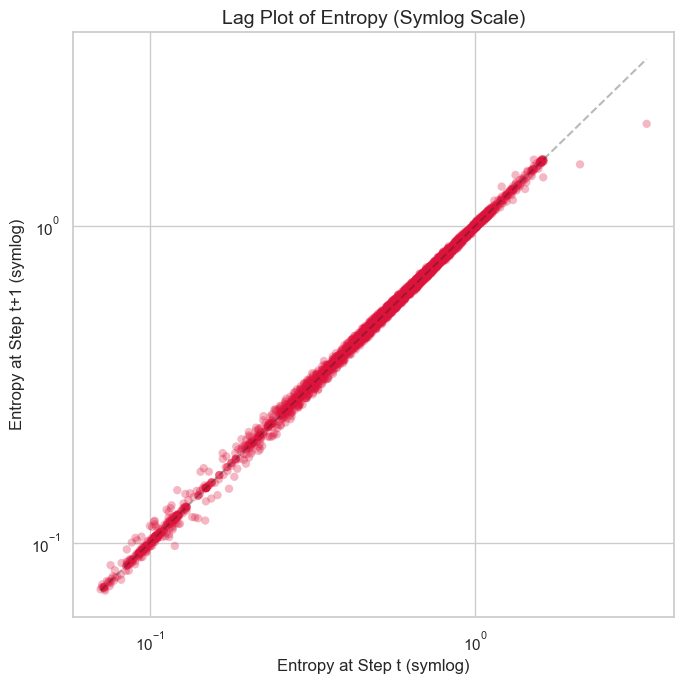

In [14]:


plt.figure(figsize=(7, 7))

# Plotting the data (alpha reduced to 0.3 to better show density in the log scale)
sns.scatterplot(
    x=df['Entropy'][:-1].values, 
    y=df['Entropy'][1:].values, 
    alpha=0.3, 
    color='crimson',
    edgecolor='none' # Removing edgecolors helps visualize overlapping points better
)

# Apply Symmetrical Log Scale to handle values near/at zero
# 'linthresh' is the threshold below which the plot remains linear
plt.xscale('symlog', linthresh=0.05)
plt.yscale('symlog', linthresh=0.05)

# Add the diagonal identity line
min_val, max_val = df['Entropy'].min(), df['Entropy'].max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3) 

plt.title('Lag Plot of Entropy (Symlog Scale)', fontsize=14)
plt.xlabel('Entropy at Step t (symlog)')
plt.ylabel('Entropy at Step t+1 (symlog)')
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_6028\710267760.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Phase', y='Entropy', palette='muted')


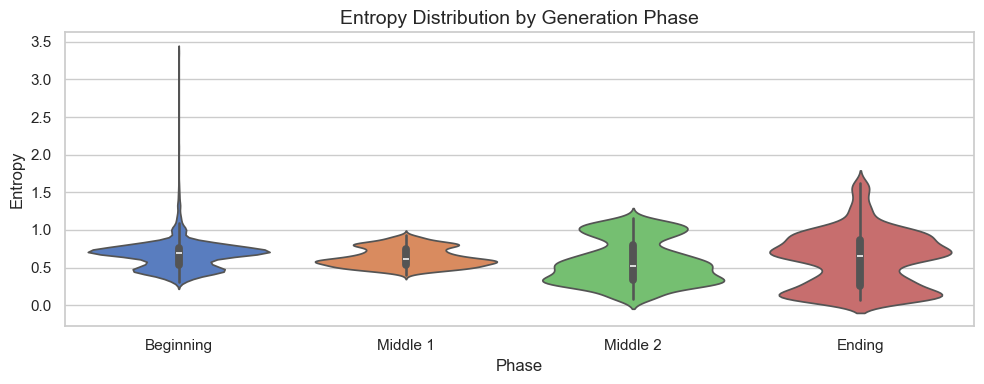

In [15]:
# Divide the generation steps into 4 equal phases
df['Phase'] = pd.qcut(df['Step'], q=4, labels=['Beginning', 'Middle 1', 'Middle 2', 'Ending'])

plt.figure(figsize=(10, 4))
sns.violinplot(data=df, x='Phase', y='Entropy', palette='muted')
plt.title('Entropy Distribution by Generation Phase', fontsize=14)
plt.ylabel('Entropy')
plt.xlabel('Phase')
plt.tight_layout()
plt.show()

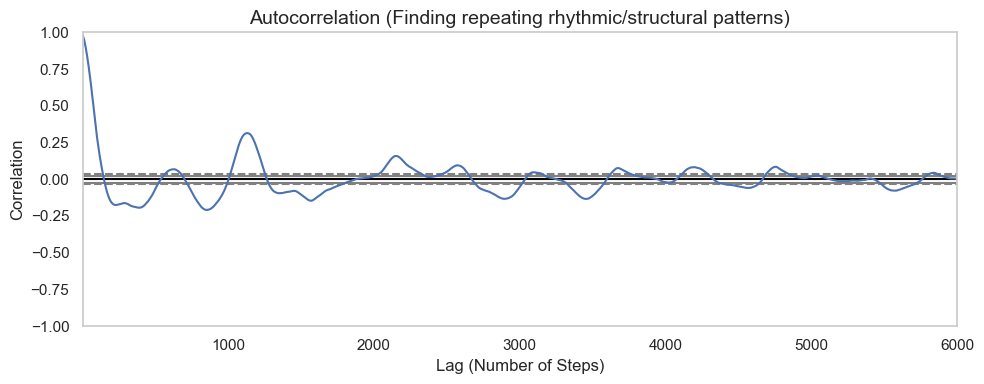

In [16]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10, 4))
autocorrelation_plot(df['Entropy'].dropna())
plt.title('Autocorrelation (Finding repeating rhythmic/structural patterns)', fontsize=14)
plt.xlabel('Lag (Number of Steps)')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()